# Tesla EV Deliveries & Production Forecasting (2015–2025)

## Problem Statement
Build an end-to-end Machine Learning pipeline on Tesla EV sales and production data, including preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time-series forecasting.

In [77]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

# print("Path to dataset files:", path)
import os
print(path)
print(os.listdir(path))

C:\Users\ASUS\.cache\kagglehub\datasets\nalisha\tesla-ea-deliveries-and-production-data20152025\versions\1
['tesla_deliveries_dataset_2015_2025.csv']


In [78]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [79]:
data = pd.read_csv(path + "/tesla_deliveries_dataset_2015_2025.csv")
df = data.copy()
print(df.head())   
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [80]:
# check missing values
df.isnull().sum()
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

Observation: The dataset is clean with no missing values and no duplicate records. Hence, no preprocessing is required at this stage.

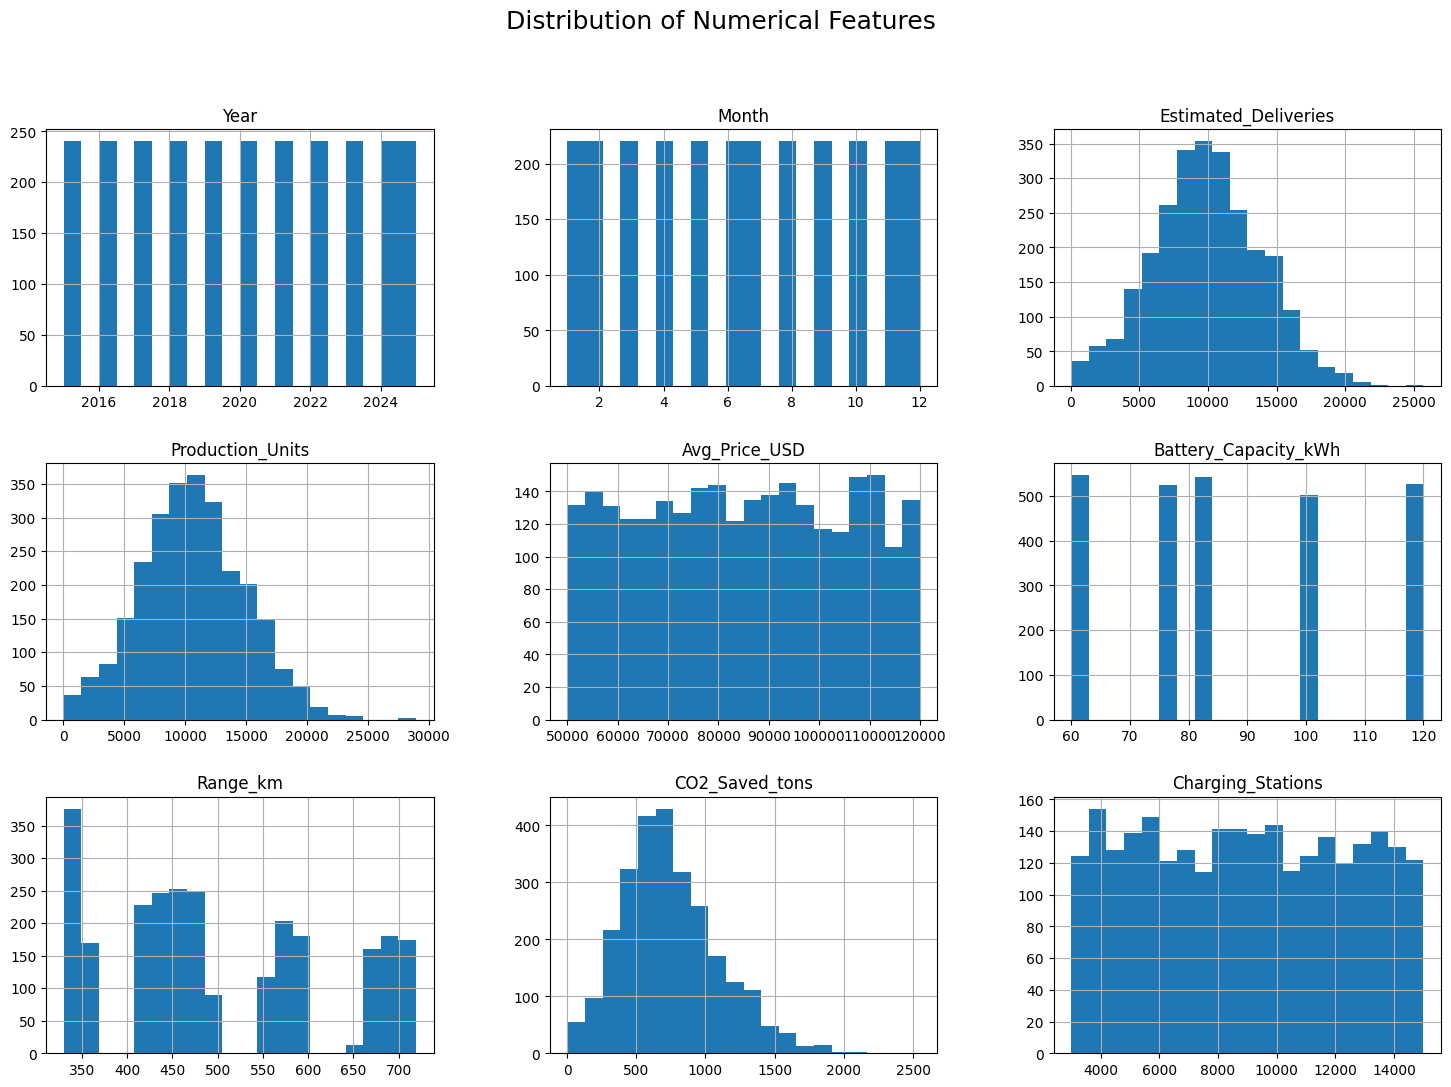

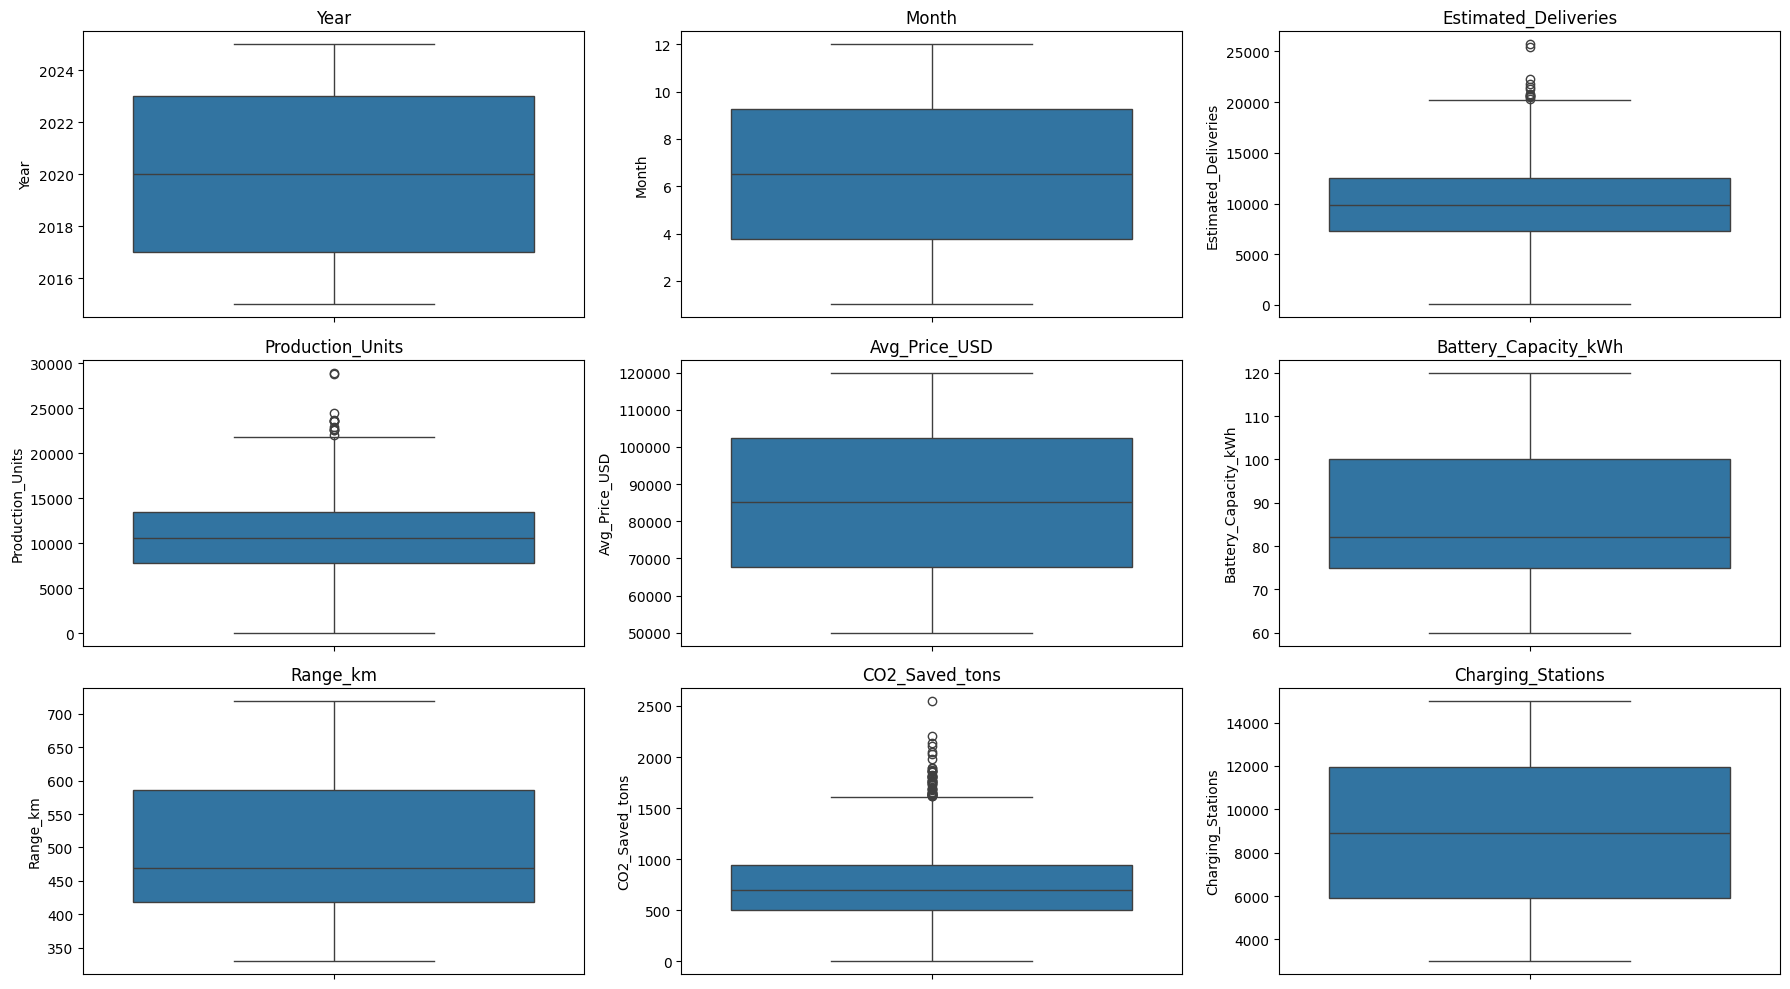

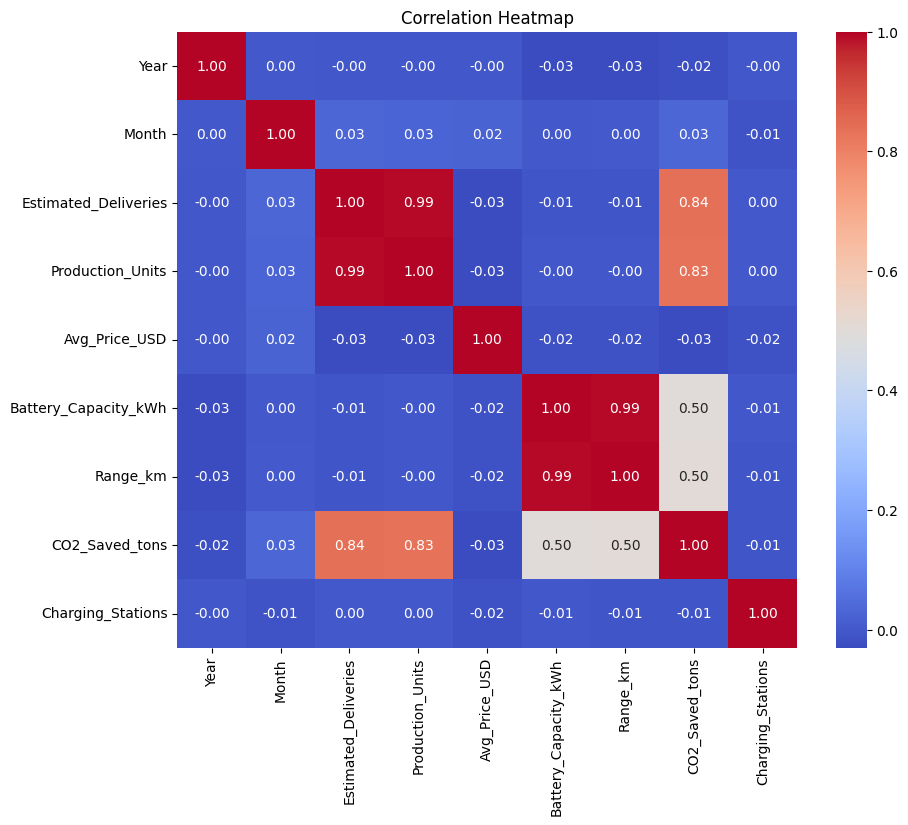

In [81]:
# numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# histogram plotting for numerical columns checking distribution spikes
df[num_cols].hist(figsize=(18, 12), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.show()

# box plot for outlier detection as it will highly effect the regression models
plt.figure(figsize=(18, 10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# corelation heatmap to check the relationship between numerical features and target variable
plt.figure(figsize=(10, 8))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

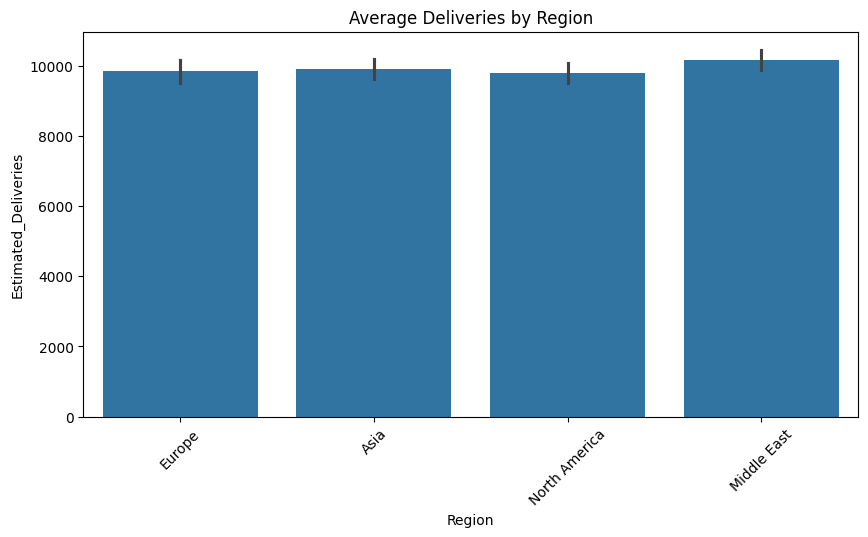

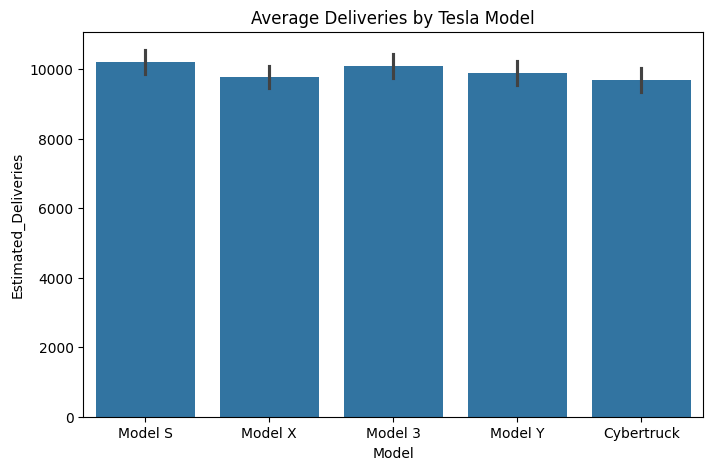

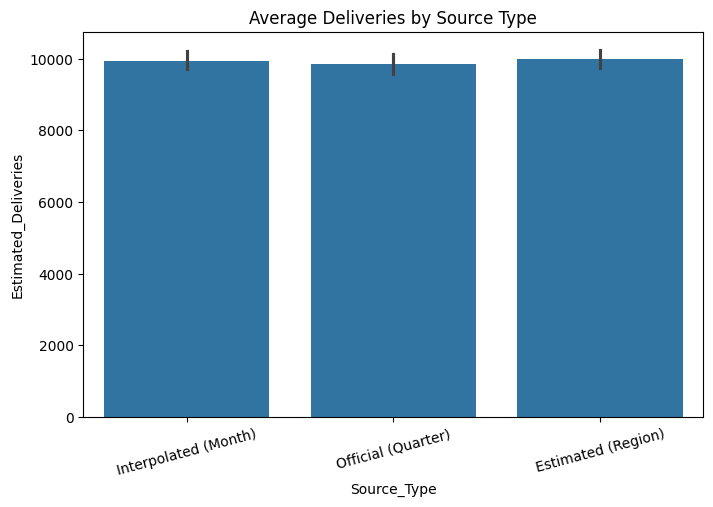

In [82]:
# Region-wise Deliveries
plt.figure(figsize=(10,5))
sns.barplot(
    x="Region",
    y="Estimated_Deliveries",
    data=df,
    estimator=np.mean
)
plt.xticks(rotation=45)
plt.title("Average Deliveries by Region")
plt.show()

# Model-wise Deliveries
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="Estimated_Deliveries",
    data=df,
    estimator=np.mean
)
plt.title("Average Deliveries by Tesla Model")
plt.show()


# Source Type
plt.figure(figsize=(8,5))
sns.barplot(
    x="Source_Type",
    y="Estimated_Deliveries",
    data=df,
    estimator=np.mean
)
plt.xticks(rotation=15)
plt.title("Average Deliveries by Source Type")
plt.show()

In [83]:
# Quarter Feature
df["Quarter"] = ((df["Month"] - 1) // 3) + 1

# Battery Efficiency
df["Battery_Efficiency"] = (
    df["Range_km"] /
    df["Battery_Capacity_kWh"]
)

# Price per KM
df["Price_per_km"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

# CO2 Saved per Vehicle
df["CO2_per_Vehicle"] = (
    df["CO2_Saved_tons"] /
    (df["Estimated_Deliveries"] + 1)
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Battery_Efficiency,Price_per_km,CO2_per_Vehicle
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2,5.866667,131.923679,0.105594
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,1,5.840000,142.022032,0.065682
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,1,5.853659,245.598583,0.071991
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,1,5.933333,125.414199,0.106783
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,4,5.508333,173.747020,0.099142


In [84]:
X = df.drop(
    ["Estimated_Deliveries"],
    axis=1
)

y = df["Estimated_Deliveries"]

In [85]:
X = pd.get_dummies(
    X,
    columns=["Region","Model","Source_Type"],
    drop_first=True
)

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

In [89]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

for name, model in models.items():

    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model","MAE","RMSE","R2"]
)

results_df.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
0,Linear Regression,309.445709,383.975031,0.990109
2,Random Forest,330.220473,415.532294,0.988416
1,Decision Tree,394.125000,527.498909,0.981333


In [90]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
0.9882987326308266


In [91]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [92]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 329.1932196969697
RMSE : 414.43145022683933
R2 Score : 0.9884777869986698


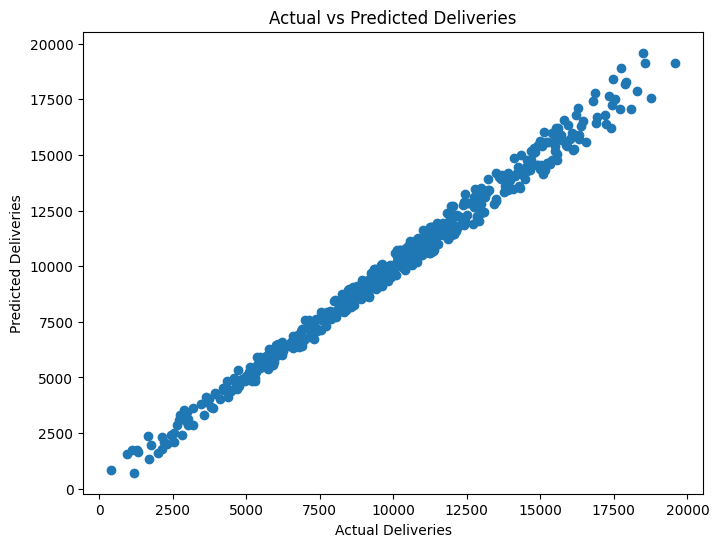

In [93]:
# Add Actual vs Predicted Plot

best_model = LinearRegression()

best_model.fit(X_train_scaled, y_train)

pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.title("Actual vs Predicted Deliveries")

plt.show()

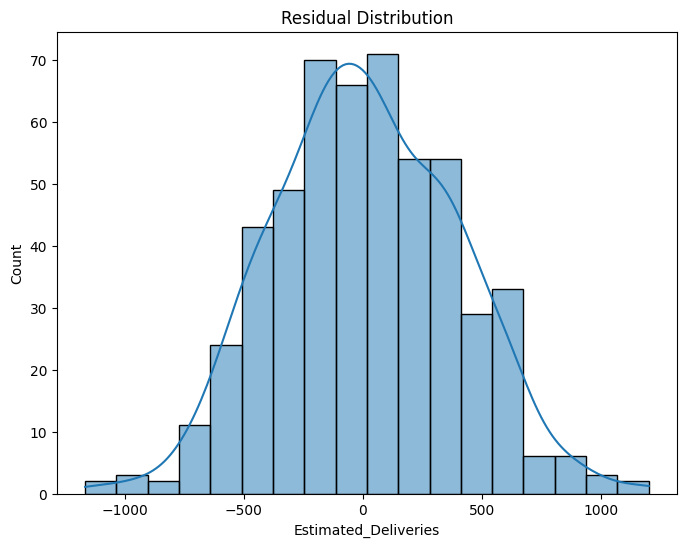

In [94]:
# Add Residual Distribution Plot
residuals = y_test - pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

## Target Leakage Investigation

During correlation analysis, it was observed that `Production_Units` had an extremely high correlation (0.99) with the target variable `Estimated_Deliveries`.

To evaluate whether the model was benefiting from target leakage, a second experiment was performed by removing `Production_Units` from the feature set and retraining the model.

This helps assess how well the model performs using only independent business features and provides a more realistic estimate of real-world predictive performance.

In [95]:
# Create a new feature set without Production_Units

X_leak_test = df.drop(
    [
        "Estimated_Deliveries",
        "Production_Units"
    ],
    axis=1
)

# One Hot Encoding

X_leak_test = pd.get_dummies(
    X_leak_test,
    columns=["Region", "Model", "Source_Type"],
    drop_first=True
)

# Train Test Split

X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_leak_test,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling

scaler_leak = StandardScaler()

X_train_leak_scaled = scaler_leak.fit_transform(X_train_leak)

X_test_leak_scaled = scaler_leak.transform(X_test_leak)

# Train Model

lr_leak = LinearRegression()

lr_leak.fit(
    X_train_leak_scaled,
    y_train_leak
)

pred_leak = lr_leak.predict(
    X_test_leak_scaled
)

# Metrics

print("R² Score without Production_Units:",
      r2_score(y_test_leak, pred_leak))

print("RMSE without Production_Units:",
      np.sqrt(mean_squared_error(y_test_leak, pred_leak)))

R² Score without Production_Units: 0.9418848546996199
RMSE without Production_Units: 930.7422311180012


## Feature Importance Analysis

Random Forest was used for feature importance analysis because tree-based models provide direct feature importance scores, helping identify the most influential factors affecting Tesla vehicle deliveries.

In [96]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
2,Production_Units,0.990468
6,CO2_Saved_tons,0.001978
3,Avg_Price_USD,0.000978
7,Charging_Stations,0.000976
9,Battery_Efficiency,0.000970
10,Price_per_km,0.000916
0,Year,0.000702
11,CO2_per_Vehicle,0.000601
5,Range_km,0.000591
1,Month,0.000535


In [97]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
)

ts = (
    df.groupby("Date")["Estimated_Deliveries"]
    .sum()
    .reset_index()
)

In [98]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


22:15:35 - cmdstanpy - INFO - Chain [1] start processing
22:15:35 - cmdstanpy - INFO - Chain [1] done processing


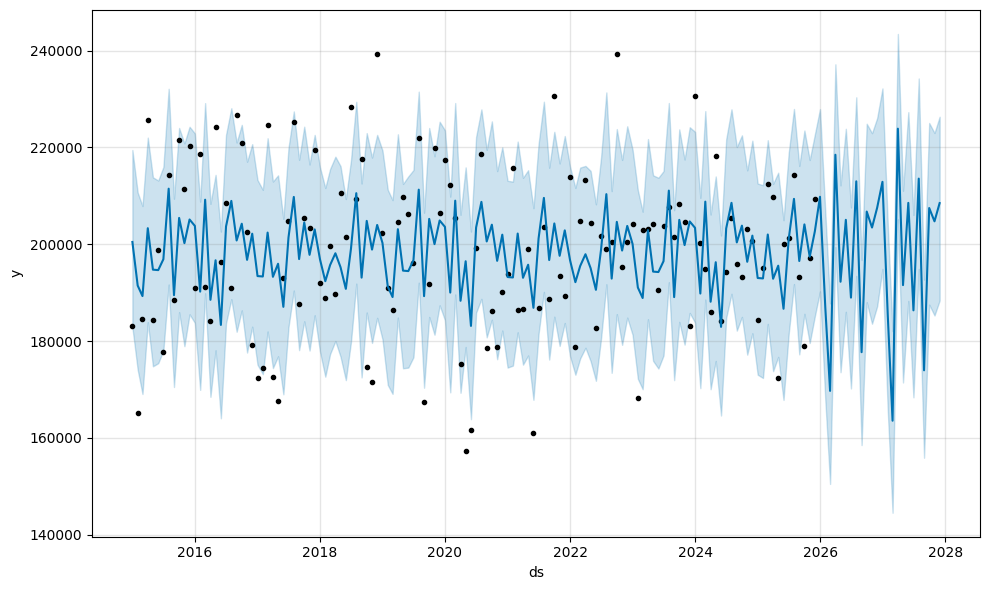

In [99]:
from prophet import Prophet

prophet_df = ts.rename(
    columns={
        "Date": "ds",
        "Estimated_Deliveries": "y"
    }
)

model = Prophet()

model.fit(prophet_df)

future = model.make_future_dataframe(
    periods=24,
    freq="ME"
)

forecast = model.predict(future)

model.plot(forecast)
plt.show()

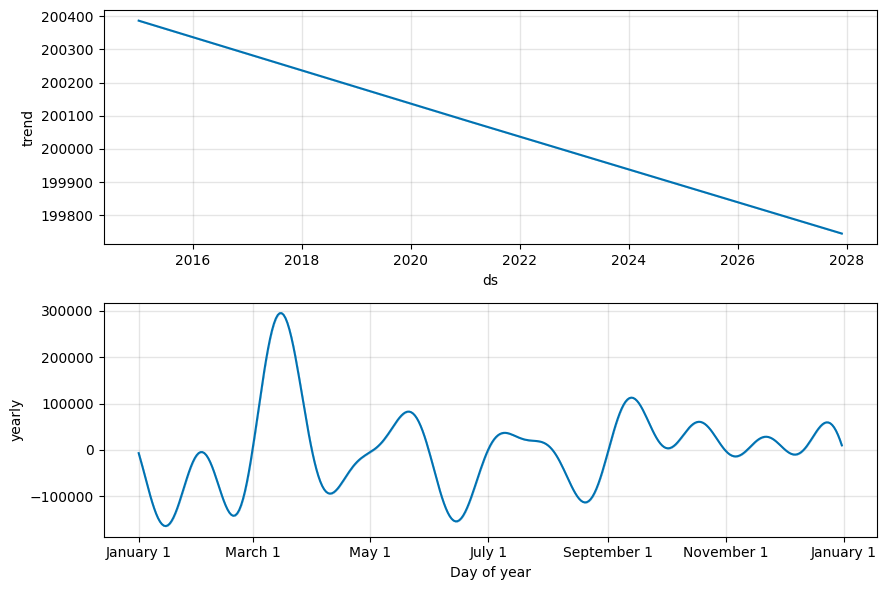

In [100]:
# Add Forecast Components Plot

model.plot_components(forecast)
plt.show()

In [101]:
import joblib

joblib.dump(
    best_model,
    "tesla_delivery_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

# Conclusion

- Developed an end-to-end Machine Learning pipeline using the Tesla EV Deliveries and Production Dataset (2015–2025).
- Performed data preprocessing, exploratory data analysis (EDA), and feature engineering to improve data quality and model performance.
- Created business-relevant features such as Battery Efficiency, Price per Kilometer, CO₂ Saved per Vehicle, and Quarter.
- Trained and evaluated multiple regression models including Linear Regression, Decision Tree Regressor, and Random Forest Regressor.
- Achieved the best performance with **Linear Regression**, obtaining:
  - **R² Score:** 0.9901
  - **MAE:** 309.45
  - **RMSE:** 383.98
- Conducted feature importance analysis to identify the key factors influencing Tesla vehicle deliveries.
- Performed a target leakage investigation by removing `Production_Units`, resulting in an **R² Score of 0.9419**, confirming the robustness of the model.
- Implemented time-series forecasting using Prophet to analyze historical trends and forecast future Tesla deliveries.
- Saved the trained model for future deployment and prediction tasks.
- Successfully demonstrated the complete machine learning lifecycle from data preprocessing to forecasting and model evaluation.